# 概要
- [Rational activationの実験](./NN_ActHikaku_4sou.ipynb)にて、3次のrational activationによるNNの学習によって構成されたFranke関数の近似関数は、複数の点で巨大な誤差が生じてしまった。原因として、活性化関数である有理関数の分母にゼロ点、すなわち極が発生してしまったと考えられる。(不必要な極の発生は有理関数近似における古典的な問題のひとつである)
- そこでratinal activationでは、活性化関数に用いる有理関数に極が発生しないような設計上の工夫が必要だと考えた
- ここでは、3次のrational activationについて「有理関数の分母に絶対値を組み込む」方法で、ゼロ点の発生を抑える手法を実装し、検証する
- 具体的には活性化関数の形を
    
    $r(x) = \frac{a_0 + a_1 x + a_2 x^2 + a_2 x^3}{1 + b_1 x + b_2 x^2 + b_3 x^3}$

    としたものと

    $r(x) = \frac{a_0 + a_1 x + a_2 x^2 + a_2 x^3}{1 + |b_1 x + b_2 x^2 + b_3 x^3|}$

    と、絶対値が入った形にしたものとで、学習結果の近似モデルの精度を比較した.

    前者の活性化関数モデルを「パターン1」,後者のそれを「パターン2」と呼ぶ

# 実験結果・考察
実験にあたって、分母の係数パラメータ$\{b_i\}$の初期値は、あえて極が発生しやすいものを選んだ。

実験の結果
- パターン1の活性化関数では極が発生し、全くもって近似が成り立っていなかった
- 一方、パターン2の活性化関数では、極が発生せず、最大相対誤差は$7 \times 10^{-3}$に抑えられた

# コードと実行結果

## 極が発生してしまう例(Before)

Rational activationモデルの訓練を開始します...
訓練が完了しました。
Max Relative Error: 1.312406


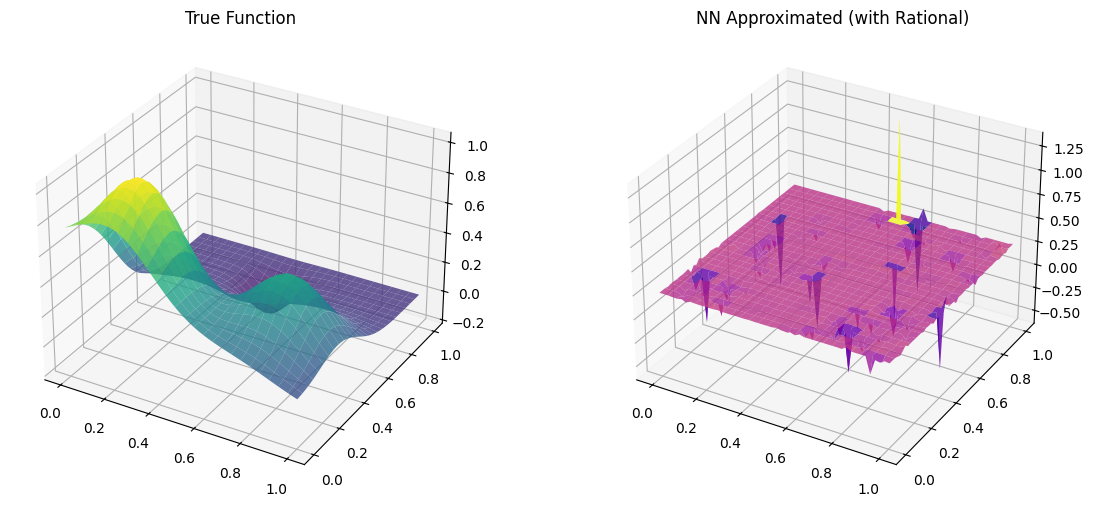

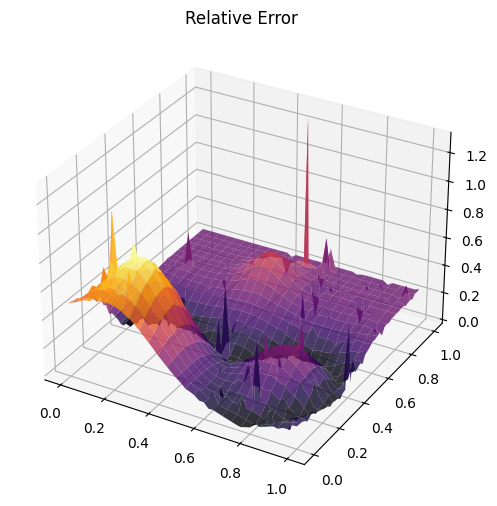

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random

# コードの最初に挿入
torch.manual_seed(42)
np.random.seed(42)

# 1. Franke関数の定義
def franke_function(x, y):
    term1 = 0.75 * np.exp(-(9*x - 2)**2 / 4 - (9*y - 2)**2 / 4)
    term2 = 0.75 * np.exp(-(9*x + 1)**2 / 49 - (9*y + 1)**2 / 10)
    term3 = 0.50 * np.exp(-(9*x - 7)**2 / 4 - (9*y - 3)**2 / 4)
    term4 = -0.2 * np.exp(-(9*x - 4)**2 - (9*y - 7)**2)
    return term1 + term2 + term3 + term4

f = franke_function

# 2. データ生成
grid_size = 50
x_coord = np.linspace(0, 1, grid_size)
y_coord = np.linspace(0, 1, grid_size)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord)
features = torch.tensor(np.stack([X_mesh.ravel(), Y_mesh.ravel()], axis=1), dtype=torch.float32)
labels = torch.tensor(f(X_mesh.ravel(), Y_mesh.ravel()), dtype=torch.float32).view(-1, 1)

class RationalActivation_deg3(nn.Module):
    def __init__(self):
        super().__init__()
        # 係数を3次まで拡張
        self.a = nn.Parameter(torch.tensor([0.0, 1.0, 0.0, 0.0])) # a0, a1, a2, a3
        self.b = nn.Parameter(torch.tensor([-4.0, 0.0, 0.0])) # b1, b2, b3
        
    def forward(self, x):
        numerator = self.a[0] + self.a[1]*x + self.a[2]*(x**2) + self.a[3]*(x**3)
        denominator = 1.0 + self.b[0]*x + self.b[1]*(x**2) + self.b[2]*(x**3)
        return numerator / (denominator + 1e-6)

# 3. モデル定義 (Rational Activation を使用)
class Rational_deg3_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),  # 幅を64に縮小
            RationalActivation_deg3(),         # 活性化関数
            nn.Linear(64, 64), # 中間層1
            RationalActivation_deg3(),
            nn.Linear(64, 64), # 中間層2
            RationalActivation_deg3(),
            nn.Linear(64, 64), # 中間層3
            RationalActivation_deg3(),
            nn.Linear(64, 1)   # 出力層
        )
    def forward(self, x):
        return self.net(x)


model = Rational_deg3_MLP()
optimizer = optim.Adam(model.parameters(), lr=0.005)
criterion = nn.MSELoss()

# 訓練
print("Rational activationモデルの訓練を開始します...")
for epoch in range(3000):
    optimizer.zero_grad()
    pred = model(features)
    loss = criterion(pred, labels)
    loss.backward()
    optimizer.step()
print("訓練が完了しました。")

# 4. 近似用ラッパー関数
def f_approx(x, y):
    coords = torch.tensor(np.stack([np.array(x).ravel(), np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析
n_eval = 51
x_eval = np.linspace(0, 1, n_eval)
y_eval = np.linspace(0, 1, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')
f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with Rational)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error")

plt.show()

## 極回避手段実装後 (After)

Rational activationモデルの訓練を開始します...
訓練が完了しました。
Max Relative Error: 0.007030


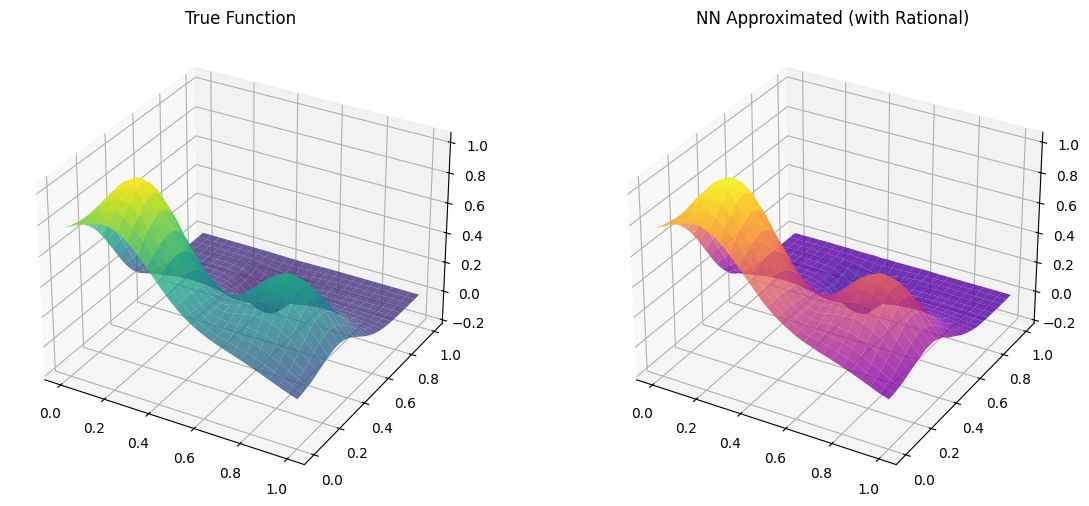

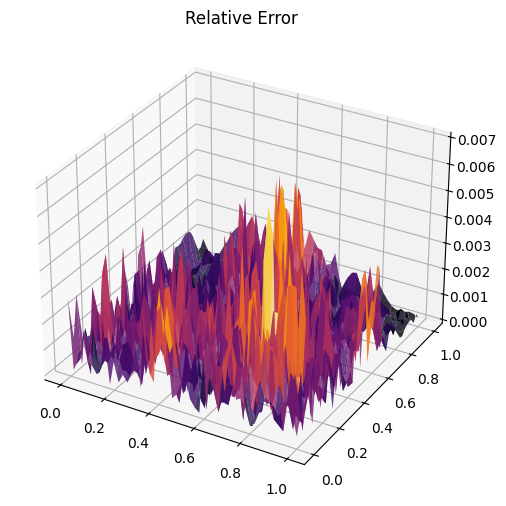

In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random

# コードの最初に挿入
torch.manual_seed(42)
np.random.seed(42)

# 1. Franke関数の定義
def franke_function(x, y):
    term1 = 0.75 * np.exp(-(9*x - 2)**2 / 4 - (9*y - 2)**2 / 4)
    term2 = 0.75 * np.exp(-(9*x + 1)**2 / 49 - (9*y + 1)**2 / 10)
    term3 = 0.50 * np.exp(-(9*x - 7)**2 / 4 - (9*y - 3)**2 / 4)
    term4 = -0.2 * np.exp(-(9*x - 4)**2 - (9*y - 7)**2)
    return term1 + term2 + term3 + term4

f = franke_function

# 2. データ生成
grid_size = 50
x_coord = np.linspace(0, 1, grid_size)
y_coord = np.linspace(0, 1, grid_size)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord)
features = torch.tensor(np.stack([X_mesh.ravel(), Y_mesh.ravel()], axis=1), dtype=torch.float32)
labels = torch.tensor(f(X_mesh.ravel(), Y_mesh.ravel()), dtype=torch.float32).view(-1, 1)

class RationalActivation_abs_ver1_deg3(nn.Module):
    def __init__(self):
        super().__init__()
        # 係数を3次まで拡張
        self.a = nn.Parameter(torch.tensor([0.0, 1.0, 0.0, 0.0])) # a0, a1, a2, a3
        self.b = nn.Parameter(torch.tensor([-4.0, 0.0, 0.0])) # b1, b2, b3
        
    def forward(self, x):
        numerator = self.a[0] + self.a[1]*x + self.a[2]*(x**2) + self.a[3]*(x**3)
        denominator = 1.0 + torch.abs(self.b[0]*x + self.b[1]*(x**2) + self.b[2]*(x**3))
        return numerator / (denominator + 1e-6)

# 3. モデル定義 (Rational Activation を使用)
class Rational_abs_ver1_deg3_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),  # 幅を64に縮小
            RationalActivation_abs_ver1_deg3(),         # 活性化関数
            nn.Linear(64, 64), # 中間層1
            RationalActivation_abs_ver1_deg3(),
            nn.Linear(64, 64), # 中間層2
            RationalActivation_abs_ver1_deg3(),
            nn.Linear(64, 64), # 中間層3
            RationalActivation_abs_ver1_deg3(),
            nn.Linear(64, 1)   # 出力層
        )
    def forward(self, x):
        return self.net(x)


model = Rational_abs_ver1_deg3_MLP()
optimizer = optim.Adam(model.parameters(), lr=0.005)
criterion = nn.MSELoss()

# 訓練
print("Rational activationモデルの訓練を開始します...")
for epoch in range(3000):
    optimizer.zero_grad()
    pred = model(features)
    loss = criterion(pred, labels)
    loss.backward()
    optimizer.step()
print("訓練が完了しました。")

# 4. 近似用ラッパー関数
def f_approx(x, y):
    coords = torch.tensor(np.stack([np.array(x).ravel(), np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析
n_eval = 51
x_eval = np.linspace(0, 1, n_eval)
y_eval = np.linspace(0, 1, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')
f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with Rational)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error")

plt.show()

# コラム
分子が3次、分母が2次の(3,2)型有理関数の場合

Rational activationモデルの訓練を開始します...
訓練が完了しました。
Max Relative Error: 0.020298


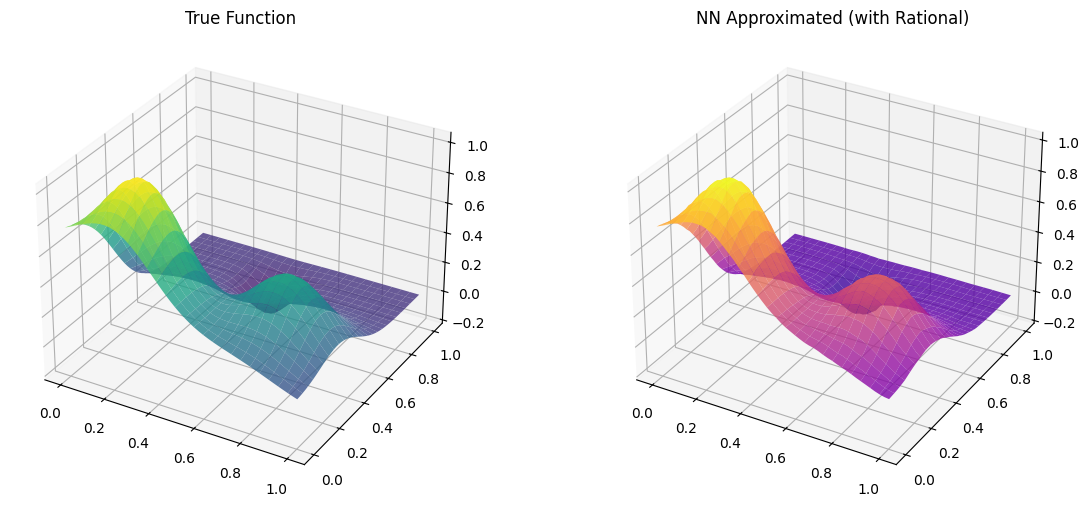

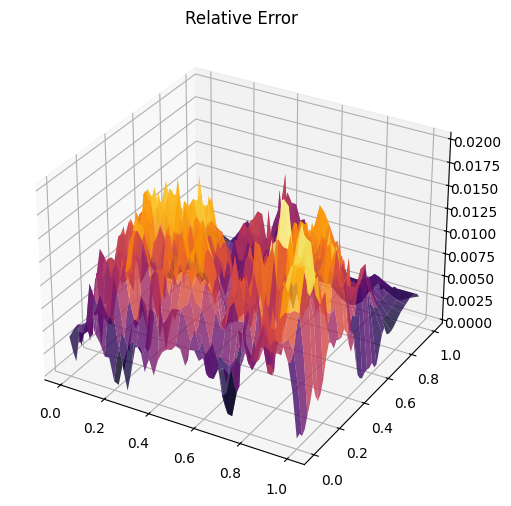

: 

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random

# コードの最初に挿入
torch.manual_seed(42)
np.random.seed(42)

# 1. Franke関数の定義
def franke_function(x, y):
    term1 = 0.75 * np.exp(-(9*x - 2)**2 / 4 - (9*y - 2)**2 / 4)
    term2 = 0.75 * np.exp(-(9*x + 1)**2 / 49 - (9*y + 1)**2 / 10)
    term3 = 0.50 * np.exp(-(9*x - 7)**2 / 4 - (9*y - 3)**2 / 4)
    term4 = -0.2 * np.exp(-(9*x - 4)**2 - (9*y - 7)**2)
    return term1 + term2 + term3 + term4

f = franke_function

# 2. データ生成
grid_size = 50
x_coord = np.linspace(0, 1, grid_size)
y_coord = np.linspace(0, 1, grid_size)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord)
features = torch.tensor(np.stack([X_mesh.ravel(), Y_mesh.ravel()], axis=1), dtype=torch.float32)
labels = torch.tensor(f(X_mesh.ravel(), Y_mesh.ravel()), dtype=torch.float32).view(-1, 1)

class RationalActivation(nn.Module):
    def __init__(self):
        super().__init__()
        # 係数を3次まで拡張
        self.a = nn.Parameter(torch.tensor([0.0, 1.0, 0.0, 0.0])) # a0, a1, a2, a3
        self.b = nn.Parameter(torch.tensor([-4.0, 0.0])) # b1, b2
        
    def forward(self, x):
        numerator = self.a[0] + self.a[1]*x + self.a[2]*(x**2) + self.a[3]*(x**3)
        denominator = 1.0 + torch.abs(self.b[0]*x + self.b[1]*(x**2))
        return numerator / (denominator + 1e-6)

# 3. モデル定義 (Rational Activation を使用)
class Rational_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),  # 幅を64に縮小
            RationalActivation(),         # 活性化関数
            nn.Linear(64, 64), # 中間層1
            RationalActivation(),
            nn.Linear(64, 64), # 中間層2
            RationalActivation(),
            nn.Linear(64, 64), # 中間層3
            RationalActivation(),
            nn.Linear(64, 1)   # 出力層
        )
    def forward(self, x):
        return self.net(x)


model = Rational_MLP()
optimizer = optim.Adam(model.parameters(), lr=0.005)
criterion = nn.MSELoss()

# 訓練
print("Rational activationモデルの訓練を開始します...")
for epoch in range(3000):
    optimizer.zero_grad()
    pred = model(features)
    loss = criterion(pred, labels)
    loss.backward()
    optimizer.step()
print("訓練が完了しました。")

# 4. 近似用ラッパー関数
def f_approx(x, y):
    coords = torch.tensor(np.stack([np.array(x).ravel(), np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析
n_eval = 51
x_eval = np.linspace(0, 1, n_eval)
y_eval = np.linspace(0, 1, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')
f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with Rational)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error")

plt.show()